Importing libraries

In [77]:
#importing neccesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


# Better display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

#better visuals setting
sns.set_theme(style="whitegrid")

<center> Phase 1: Data Cleaning

In [78]:
#loadind data
transactions = pd.read_excel('../data/raw/QVI_transaction_data.xlsx')
customers = pd.read_csv('../data/raw/QVI_purchase_behaviour.csv')

In [79]:
#first glance of both tables
transactions.head()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [80]:
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [81]:
# structure checking
transactions.info()


<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264836 non-null  datetime64[us]
 1   STORE_NBR       264836 non-null  int64         
 2   LYLTY_CARD_NBR  264836 non-null  int64         
 3   TXN_ID          264836 non-null  int64         
 4   PROD_NBR        264836 non-null  int64         
 5   PROD_NAME       264836 non-null  str           
 6   PROD_QTY        264836 non-null  int64         
 7   TOT_SALES       264836 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(5), str(1)
memory usage: 16.2 MB


In [82]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [83]:
# basic statistics

transactions.describe()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [84]:
transactions['PROD_NAME'].head(20)


0       Natural Chip        Compny SeaSalt175g
1                     CCs Nacho Cheese    175g
2       Smiths Crinkle Cut  Chips Chicken 170g
3       Smiths Chip Thinly  S/Cream&Onion 175g
4     Kettle Tortilla ChpsHny&Jlpno Chili 150g
5     Old El Paso Salsa   Dip Tomato Mild 300g
6     Smiths Crinkle Chips Salt & Vinegar 330g
7        Grain Waves         Sweet Chilli 210g
8      Doritos Corn Chip Mexican Jalapeno 150g
9        Grain Waves Sour    Cream&Chives 210G
10    Smiths Crinkle Chips Salt & Vinegar 330g
11       Kettle Sensations   Siracha Lime 150g
12                    Twisties Cheese     270g
13            WW Crinkle Cut      Chicken 175g
14              Thins Chips Light&  Tangy 175g
15                           CCs Original 175g
16                           Burger Rings 220g
17      NCC Sour Cream &    Garden Chives 175g
18     Doritos Corn Chip Southern Chicken 150g
19                    Cheezels Cheese Box 125g
Name: PROD_NAME, dtype: str

In [85]:

products = transactions['PROD_NAME'].unique()

products_df = pd.DataFrame(products, columns=['PRODUCT'])

products_df = products_df.sort_values(by='PRODUCT')

products_df.head(114)

,PRODUCT
15,Burger Rings 220g
1,CCs Nacho Cheese 175g
14,CCs Original 175g
87,CCs Tasty Cheese 175g
95,Cheetos Chs & Bacon Balls 190g
...,...
106,WW Sour Cream &OnionStacked Chips 160g
91,WW Supreme Cheese Corn Chips 200g
88,Woolworths Cheese Rings 190g
85,Woolworths Medium Salsa 300g


In [86]:
transactions['PROD_NAME'].str.lower().str.contains('salsa|dip').sum()

np.int64(19532)

In [87]:
words = transactions['PROD_NAME'].str.lower().str.split().explode()
words.value_counts().head(100)

PROD_NAME
175g             60561
chips            49770
150g             43131
kettle           41288
&                35565
smiths           28860
salt             27976
cheese           27890
pringles         25102
134g             25102
doritos          24962
crinkle          23960
110g             22387
corn             22063
original         21560
cut              20754
chip             18645
170g             18502
salsa            18094
chicken          15407
165g             15297
sea              14145
thins            14075
sour             13882
crisps           12607
330g             12540
vinegar          12402
chilli           12389
300g             12041
rrd              11894
infuzions        11057
supreme          10963
ww               10320
cobs              9693
popd              9693
tortilla          9580
tostitos          9471
twisties          9454
sensations        9429
old               9324
el                9324
paso              9324
dip               9324
s

In [88]:
#as we are specifically working on chips, we can remove rows having salsa or dip bcs they are not my target
transactions = transactions[
    ~transactions['PROD_NAME'].str.lower().str.contains('salsa|dip')
]

In [89]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,245304,245304.000000,2.453040e+05,2.453040e+05,245304.000000,245304.000000,245304.000000
mean,2018-12-30 01:25:33.196360,135.053322,1.355352e+05,1.351340e+05,56.054883,1.908200,7.335517
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001400e+04,6.755875e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303675e+05,1.351865e+05,52.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030862e+05,2.026662e+05,86.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.796402,8.074658e+04,7.815838e+04,33.569505,0.661172,3.080377


In [90]:
transactions[transactions['PROD_QTY'] > 20].shape
transactions = transactions[transactions['PROD_QTY'] <= 20]

In [91]:
transactions['PROD_QTY'].max()

np.int64(5)

In [92]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,245302,245302.000000,2.453020e+05,2.453020e+05,245302.000000,245302.000000,245302.000000
mean,2018-12-30 01:25:30.420461,135.052580,1.355344e+05,1.351333e+05,56.055307,1.906585,7.330277
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001400e+04,6.755825e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351855e+05,52.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030860e+05,2.026648e+05,86.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.796276,8.074650e+04,7.815827e+04,33.569313,0.342363,2.474134


In [93]:
customers.head(20)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


In [94]:
customers['LIFESTAGE'].value_counts()

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [95]:
customers['PREMIUM_CUSTOMER'].value_counts()

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

<center> Phase 2: Feature Engineering

In [96]:
# extracting pack size to create a new variable pack size
transactions['PACK_SIZE'] = transactions['PROD_NAME'].str.extract(r'(\d+)').astype(int)

In [97]:
transactions[['PROD_NAME', 'PACK_SIZE']].head(10)

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175
1,CCs Nacho Cheese 175g,175
2,Smiths Crinkle Cut Chips Chicken 170g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150
6,Smiths Crinkle Chips Salt & Vinegar 330g,330
7,Grain Waves Sweet Chilli 210g,210
8,Doritos Corn Chip Mexican Jalapeno 150g,150
9,Grain Waves Sour Cream&Chives 210G,210
10,Smiths Crinkle Chips Salt & Vinegar 330g,330


In [98]:
transactions['PACK_SIZE'].value_counts().sort_index()

PACK_SIZE
70      1507
90      3008
110    22387
125     1454
134    25102
135     3257
150    38765
160     2970
165    15297
170    19983
175    66390
180     1468
190     2995
200     4473
210     6272
220     1564
250     3169
270     6285
330    12540
380     6416
Name: count, dtype: int64

In [99]:
# now extracting brand name
transactions['BRAND'] = transactions['PROD_NAME'].str.split().str[0]

In [100]:
transactions[['PROD_NAME', 'BRAND']].head(10)


,PROD_NAME,BRAND
0,Natural Chip Compny SeaSalt175g,Natural
1,CCs Nacho Cheese 175g,CCs
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle
6,Smiths Crinkle Chips Salt & Vinegar 330g,Smiths
7,Grain Waves Sweet Chilli 210g,Grain
8,Doritos Corn Chip Mexican Jalapeno 150g,Doritos
9,Grain Waves Sour Cream&Chives 210G,Grain
10,Smiths Crinkle Chips Salt & Vinegar 330g,Smiths


In [101]:

transactions['BRAND'].value_counts().head(30)


BRAND
Kettle        41288
Smiths        25952
Pringles      25102
Doritos       22041
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Cheezels       4603
CCs            4551
Red            4427
Dorito         3183
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Woolworths     1516
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64

In [102]:
brands = transactions['BRAND'].unique()
brands_df = pd.DataFrame(brands, columns=['BRAND']).sort_values(by='BRAND')
brands_df

,BRAND
9,Burger
1,CCs
24,Cheetos
11,Cheezels
20,Cobs
15,Dorito
5,Doritos
21,French
4,Grain
18,GrnWves


In [103]:
#after observing aboce coloum, we found minor inconsistencies in brand naming which we will correct by mapping
brand_mapping = {
    'Dorito': 'Doritos',
    'Infzns': 'Infuzions',
    'GrnWves': 'Grain Waves',
    'Grain' : 'Grain Waves', 
    'Natural': 'Natural Chip Co',
    'French': 'French Fries',
    'Burger': 'Burger Rings',
    'WW': 'Woolworths',
    'Snbts' : 'Sunbites',
    'Smith' : 'Smiths',
    'Red' : 'Red Rock Deli',
    'RRD' : 'Red Rock Deli',
    'NCC' : 'Natural Chip Co'
}

transactions['BRAND'] = transactions['BRAND'].replace(brand_mapping)

In [104]:
transactions['BRAND'].value_counts()

BRAND
Kettle             41288
Smiths             28915
Doritos            25224
Pringles           25102
Red Rock Deli      16321
Infuzions          14201
Thins              14075
Woolworths         11836
Cobs                9693
Tostitos            9471
Twisties            9454
Grain Waves         7740
Natural Chip Co     7469
Tyrrells            6442
Cheezels            4603
CCs                 4551
Sunbites            3008
Cheetos             2927
Burger Rings        1564
French Fries        1418
Name: count, dtype: int64

In [105]:
merged_data = pd.merge(
    transactions,
    customers,
    on='LYLTY_CARD_NBR',
    how='left'
)

In [106]:
merged_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural Chip Co,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [107]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 245302 entries, 0 to 245301
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              245302 non-null  datetime64[us]
 1   STORE_NBR         245302 non-null  int64         
 2   LYLTY_CARD_NBR    245302 non-null  int64         
 3   TXN_ID            245302 non-null  int64         
 4   PROD_NBR          245302 non-null  int64         
 5   PROD_NAME         245302 non-null  str           
 6   PROD_QTY          245302 non-null  int64         
 7   TOT_SALES         245302 non-null  float64       
 8   PACK_SIZE         245302 non-null  int64         
 9   BRAND             245302 non-null  object        
 10  LIFESTAGE         245302 non-null  str           
 11  PREMIUM_CUSTOMER  245302 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(6), object(1), str(3)
memory usage: 22.5+ MB


In [108]:
merged_data[['LIFESTAGE', 'PREMIUM_CUSTOMER']].isnull().sum()

LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [109]:
merged_data['LIFESTAGE'].value_counts()

LIFESTAGE
OLDER SINGLES/COUPLES     50489
RETIREES                  46203
OLDER FAMILIES            44865
YOUNG FAMILIES            40219
YOUNG SINGLES/COUPLES     33787
MIDAGE SINGLES/COUPLES    23273
NEW FAMILIES               6466
Name: count, dtype: int64

In [110]:
merged_data['PREMIUM_CUSTOMER'].value_counts()

PREMIUM_CUSTOMER
Mainstream    94546
Budget        86191
Premium       64565
Name: count, dtype: int64

<center>Phase 3: Data Enrichment and Busines Insights

In [111]:
# finding Which customer group generates the most revenue?
merged_data.groupby('LIFESTAGE')['TOT_SALES'].sum().sort_values(ascending=False)

LIFESTAGE
OLDER SINGLES/COUPLES     374516.85
RETIREES                  341276.90
OLDER FAMILIES            327056.10
YOUNG FAMILIES            293247.30
YOUNG SINGLES/COUPLES     242927.20
MIDAGE SINGLES/COUPLES    171905.00
NEW FAMILIES               47202.35
Name: TOT_SALES, dtype: float64

In [112]:
# Which type of customer spends the most? 
merged_data.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].sum().sort_values(ascending=False)

PREMIUM_CUSTOMER
Mainstream    698426.60
Budget        628606.65
Premium       471098.45
Name: TOT_SALES, dtype: float64

The highest revenue is driven by older singles/couples within the mainstream segment, suggesting that targeting this group could yield the greatest commercial impact.

In [113]:
# this gives avg spend per group of lifestage
merged_data.groupby('LIFESTAGE')['TOT_SALES'].mean().sort_values(ascending=False)

LIFESTAGE
OLDER SINGLES/COUPLES     7.417791
RETIREES                  7.386466
MIDAGE SINGLES/COUPLES    7.386456
NEW FAMILIES              7.300085
YOUNG FAMILIES            7.291263
OLDER FAMILIES            7.289783
YOUNG SINGLES/COUPLES     7.189961
Name: TOT_SALES, dtype: float64

In [114]:
# this gives avg spend by each type of customer
merged_data.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].mean().sort_values(ascending=False)

PREMIUM_CUSTOMER
Mainstream    7.387162
Premium       7.296499
Budget        7.293182
Name: TOT_SALES, dtype: float64

Revenue differences across segments are driven more by purchase frequency than by spend per transaction.

In [115]:
# checking the purchase frequency now based on the above observation
merged_data.groupby('LYLTY_CARD_NBR')['TXN_ID'].nunique().describe()

count    71185.000000
mean         3.425441
std          2.418167
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         17.000000
Name: TXN_ID, dtype: float64

In [116]:
merged_data.groupby(['LIFESTAGE', 'LYLTY_CARD_NBR'])['TXN_ID'].nunique().groupby('LIFESTAGE').mean().sort_values(ascending=False)

LIFESTAGE
OLDER FAMILIES            4.623687
YOUNG FAMILIES            4.420441
OLDER SINGLES/COUPLES     3.493599
MIDAGE SINGLES/COUPLES    3.243376
RETIREES                  3.164705
NEW FAMILIES              2.589795
YOUNG SINGLES/COUPLES     2.403454
Name: TXN_ID, dtype: float64

While families purchase more frequently, older singles/couples generate higher revenue, suggesting higher-value purchases rather than higher frequency.

In [117]:
# extracting avg quantity per lifestage
merged_data.groupby('LIFESTAGE')['PROD_QTY'].mean().sort_values(ascending=False)

LIFESTAGE
OLDER FAMILIES            1.946573
YOUNG FAMILIES            1.940526
OLDER SINGLES/COUPLES     1.913427
MIDAGE SINGLES/COUPLES    1.901689
RETIREES                  1.892734
NEW FAMILIES              1.858027
YOUNG SINGLES/COUPLES     1.834463
Name: PROD_QTY, dtype: float64

The business insight from all of this is that the Older singles/couples generate the highest revenue despite not purchasing most frequently, indicating a preference for higher-value products. In contrast, families purchase more often and in slightly higher quantities but contribute less revenue, suggesting more price-sensitive behavior.

In [118]:
# finding whether different segments prefer different pack sizes?
merged_data.groupby('LIFESTAGE')['PACK_SIZE'].mean().sort_values(ascending=False)

LIFESTAGE
YOUNG SINGLES/COUPLES     176.485068
MIDAGE SINGLES/COUPLES    176.215830
RETIREES                  176.007813
OLDER SINGLES/COUPLES     175.688130
OLDER FAMILIES            175.366901
NEW FAMILIES              175.287195
YOUNG FAMILIES            175.045526
Name: PACK_SIZE, dtype: float64

There is minimal variation in pack size, quantity, and average spend across customer segments. The key driver of revenue differences is purchase frequency and segment size, with older singles/couples contributing the most revenue despite lower purchase frequency, indicating a higher-value customer base.

In [119]:
# removing the 175 gram pack to see who buys the other packing the most
filtered_data = merged_data[merged_data['PACK_SIZE'] != 175]

In [120]:
filtered_data.groupby('LIFESTAGE')['TXN_ID'].count().sort_values(ascending=False)

LIFESTAGE
OLDER SINGLES/COUPLES     36881
RETIREES                  33755
OLDER FAMILIES            32653
YOUNG FAMILIES            29126
YOUNG SINGLES/COUPLES     24834
MIDAGE SINGLES/COUPLES    16939
NEW FAMILIES               4724
Name: TXN_ID, dtype: int64

In [121]:
filtered_data.groupby('PREMIUM_CUSTOMER')['TXN_ID'].count().sort_values(ascending=False)

PREMIUM_CUSTOMER
Mainstream    69403
Budget        62598
Premium       46911
Name: TXN_ID, dtype: int64

In [122]:
filtered_data.groupby(['LIFESTAGE', 'PACK_SIZE'])['TXN_ID'].count().unstack().fillna(0)

PACK_SIZE,70,90,110,125,134,135,150,160,165,170,180,190,200,210,220,250,270,330,380
LIFESTAGE,,,,,,,,,,,,,,,,,,,
MIDAGE SINGLES/COUPLES,141,249,2223,108,2389,309,3630,290,1448,1835,119,266,388,613,152,282,649,1220,628
NEW FAMILIES,28,61,653,53,698,91,1016,67,369,521,30,71,106,183,40,77,156,319,185
OLDER FAMILIES,311,622,3809,297,4244,534,7157,638,3009,3684,339,652,993,1090,353,563,1081,2205,1072
OLDER SINGLES/COUPLES,308,584,4690,306,5307,740,8048,583,2962,4078,292,599,877,1311,292,668,1281,2599,1356
RETIREES,263,535,4340,256,4951,630,7324,483,2725,3764,252,461,731,1214,256,665,1225,2439,1241
YOUNG FAMILIES,274,596,3445,257,3829,501,6369,521,2707,3350,273,577,840,948,293,466,946,1955,979
YOUNG SINGLES/COUPLES,182,361,3227,177,3684,452,5221,388,2077,2751,163,369,538,913,178,448,947,1803,955


In [123]:
merged_data.groupby(['LIFESTAGE', 'PACK_SIZE'])['TXN_ID'].count().unstack().fillna(0)

PACK_SIZE,70,90,110,125,134,135,150,160,165,170,175,180,190,200,210,220,250,270,330,380
LIFESTAGE,,,,,,,,,,,,,,,,,,,,
MIDAGE SINGLES/COUPLES,141,249,2223,108,2389,309,3630,290,1448,1835,6334,119,266,388,613,152,282,649,1220,628
NEW FAMILIES,28,61,653,53,698,91,1016,67,369,521,1742,30,71,106,183,40,77,156,319,185
OLDER FAMILIES,311,622,3809,297,4244,534,7157,638,3009,3684,12212,339,652,993,1090,353,563,1081,2205,1072
OLDER SINGLES/COUPLES,308,584,4690,306,5307,740,8048,583,2962,4078,13608,292,599,877,1311,292,668,1281,2599,1356
RETIREES,263,535,4340,256,4951,630,7324,483,2725,3764,12448,252,461,731,1214,256,665,1225,2439,1241
YOUNG FAMILIES,274,596,3445,257,3829,501,6369,521,2707,3350,11093,273,577,840,948,293,466,946,1955,979
YOUNG SINGLES/COUPLES,182,361,3227,177,3684,452,5221,388,2077,2751,8953,163,369,538,913,178,448,947,1803,955


Excluding the dominant 175g pack, smaller pack sizes are more commonly purchased by singles, particularly younger segments, while larger pack sizes are preferred by family segments, indicating bulk purchasing behavior. Older singles/couples show consistent purchasing across all pack sizes, reinforcing their role as the most valuable and versatile customer segment.

In [124]:
#starting from basics of business to gain deep unedrstadning of sales analysis
# total revenue
total_revenue = merged_data['TOT_SALES'].sum()
print(f"total revenue: {total_revenue}")

#sales over time
sales_trend = merged_data.groupby('DATE')['TOT_SALES'].sum()

print(f"sales over time: \n {sales_trend.head(10)}")

total revenue: 1798131.7
sales over time: 
 DATE
2018-07-01    4888.9
2018-07-02    4861.4
2018-07-03    4920.9
2018-07-04    4957.7
2018-07-05    4653.4
2018-07-06    5228.6
2018-07-07    4951.9
2018-07-08    4719.2
2018-07-09    5135.4
2018-07-10    4674.0
Name: TOT_SALES, dtype: float64


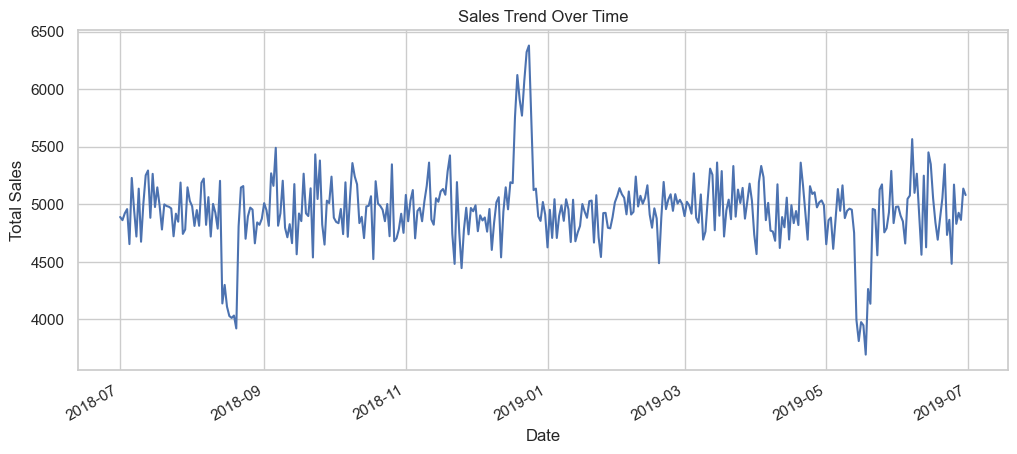

In [125]:
#plotting the sales trend
sales_trend.plot(figsize=(12,5))
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

In [126]:
#extracting top products 
top_products = merged_data.groupby('PROD_NAME')['TOT_SALES'].sum().sort_values(ascending=False)
print(f"top 10 products along with total revenue generated:\n {top_products.head(10)}")
print()
#extracting top stores
top_stores = merged_data.groupby('STORE_NBR')['TOT_SALES'].sum().sort_values(ascending=False)
print(f"top 10 stores with reveue they generated: \n {top_stores.head(10)}")


top 10 products along with total revenue generated:
 PROD_NAME
Dorito Corn Chp     Supreme 380g            39052.0
Smiths Crnkle Chip  Orgnl Big Bag 380g      36367.6
Smiths Crinkle Chips Salt & Vinegar 330g    34804.2
Kettle Mozzarella   Basil & Pesto 175g      34457.4
Smiths Crinkle      Original 330g           34302.6
Cheezels Cheese 330g                        34296.9
Doritos Cheese      Supreme 330g            33390.6
Kettle Sweet Chilli And Sour Cream 175g     33031.8
Kettle Original 175g                        32740.2
Kettle Sea Salt     And Vinegar 175g        32589.0
Name: TOT_SALES, dtype: float64

top 10 stores with reveue they generated: 
 STORE_NBR
226    16544.65
88     15445.85
165    15188.35
237    14830.60
40     14427.30
58     14256.95
199    13975.90
4      13709.25
203    13623.40
26     13597.20
Name: TOT_SALES, dtype: float64


-  Sales remain relatively stable over time with occasional spikes and dips, indicating consistent demand with periodic fluctuations likely driven by promotions or seasonality.
- A small set of brands dominate revenue, particularly larger pack variants (330g–380g), indicating strong consumer preference for well-known brands and larger sizes.
- Revenue is unevenly distributed across stores, with a few high-performing locations contributing significantly more sales.

sales by lifestage: 
 LIFESTAGE
OLDER SINGLES/COUPLES     374516.85
RETIREES                  341276.90
OLDER FAMILIES            327056.10
YOUNG FAMILIES            293247.30
YOUNG SINGLES/COUPLES     242927.20
MIDAGE SINGLES/COUPLES    171905.00
NEW FAMILIES               47202.35
Name: TOT_SALES, dtype: float64



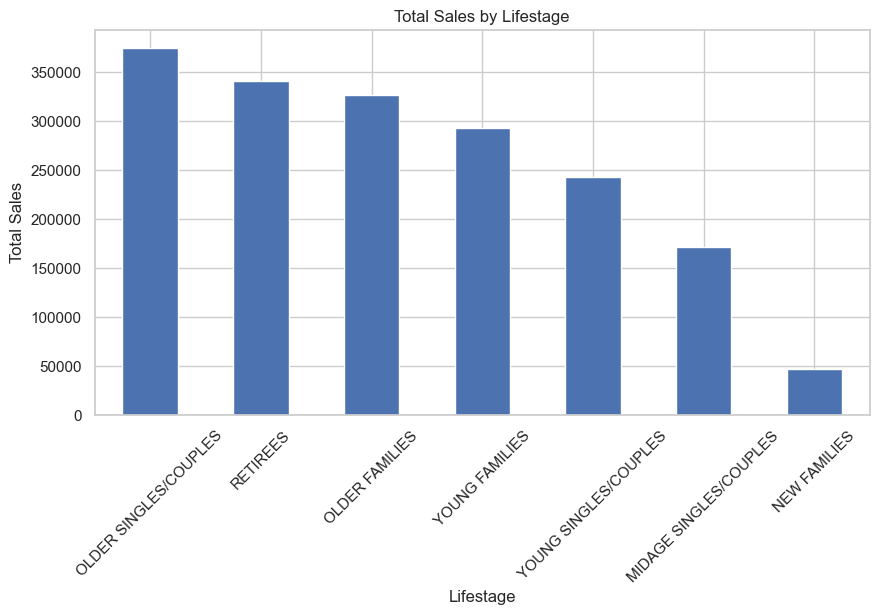


sales by premium customers: 
 PREMIUM_CUSTOMER
Mainstream    698426.60
Budget        628606.65
Premium       471098.45
Name: TOT_SALES, dtype: float64



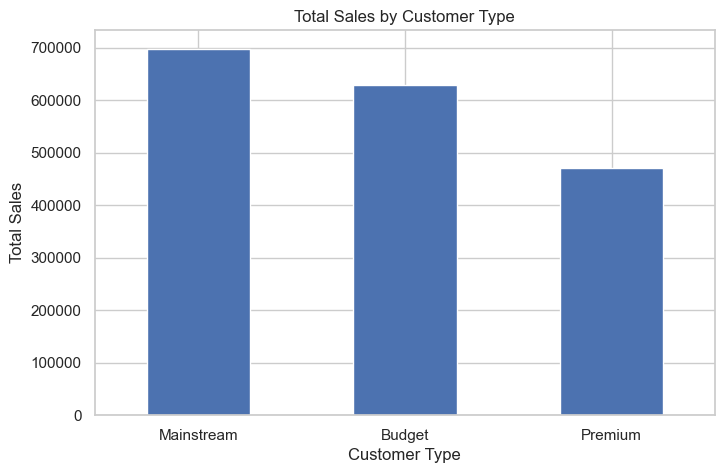

combined segment analysis: 
 PREMIUM_CUSTOMER           Budget  Mainstream    Premium
LIFESTAGE                                               
MIDAGE SINGLES/COUPLES   33150.70    84500.25   54254.05
NEW FAMILIES             20534.65    15935.50   10732.20
OLDER FAMILIES          156096.75    96059.95   74899.40
OLDER SINGLES/COUPLES   127279.80   124089.50  123147.55
RETIREES                105586.10   144677.55   91013.25
YOUNG FAMILIES          129151.15    85919.65   78176.50
YOUNG SINGLES/COUPLES    56807.50   147244.20   38875.50



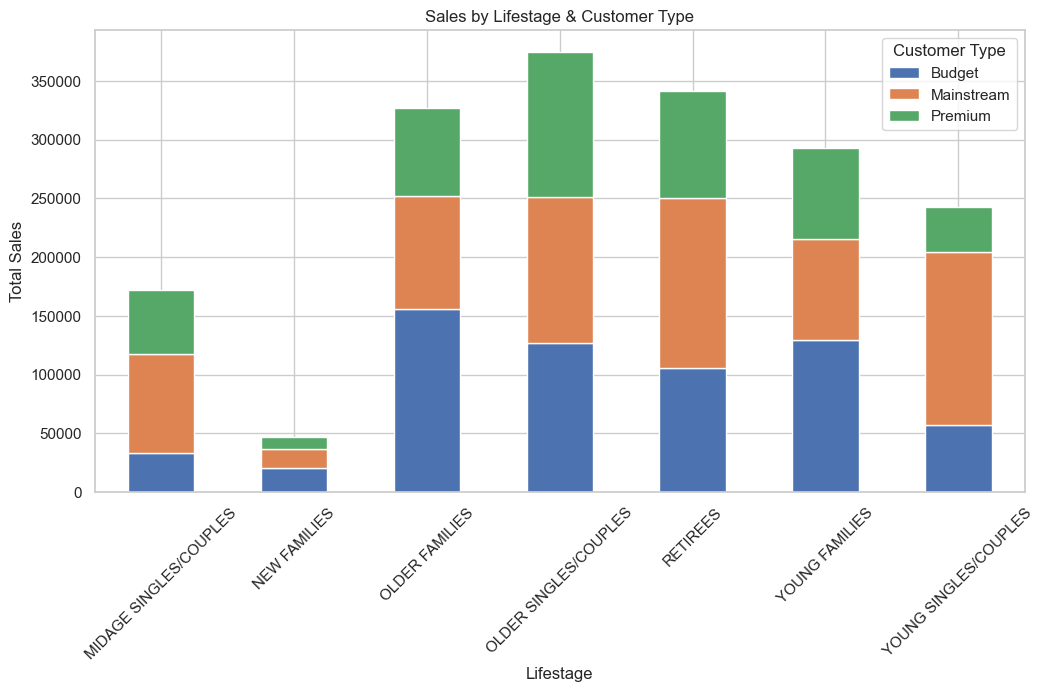

In [127]:
# sales by lifestage
sales_lifestage = merged_data.groupby('LIFESTAGE')['TOT_SALES'].sum().sort_values(ascending=False)
print(f"sales by lifestage: \n {sales_lifestage}")
print()
# visualization 
sales_lifestage.plot(kind='bar', figsize=(10,5))
plt.title("Total Sales by Lifestage")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

print()
# sales by premium customers
sales_premium = merged_data.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].sum().sort_values(ascending=False)
print(f"sales by premium customers: \n {sales_premium}")
print()
#visualization
sales_premium.plot(kind='bar', figsize=(8,5))
plt.title("Total Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()


#combined segment analysis
segment_sales = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack()
print(f"combined segment analysis: \n {segment_sales}")
print()
#visulaization
segment_sales.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Sales by Lifestage & Customer Type")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.legend(title="Customer Type")

plt.show()

Older singles/couples represent the highest revenue-generating segment, with balanced spending across all customer types. Mainstream customers dominate overall revenue, particularly within retirees and young singles. Families contribute significantly through budget-oriented purchases, indicating price sensitivity and bulk buying behavior.

average quantity per transaction: 
 LIFESTAGE
OLDER FAMILIES            1.946573
YOUNG FAMILIES            1.940526
OLDER SINGLES/COUPLES     1.913427
MIDAGE SINGLES/COUPLES    1.901689
RETIREES                  1.892734
NEW FAMILIES              1.858027
YOUNG SINGLES/COUPLES     1.834463
Name: PROD_QTY, dtype: float64



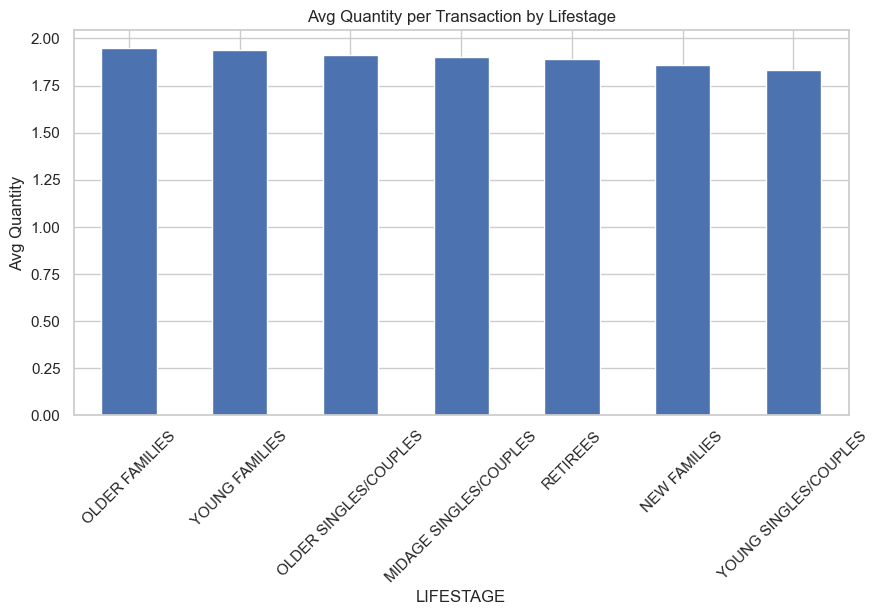


Transaction per customer: 
 count    71185.000000
mean         3.425441
std          2.418167
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         17.000000
Name: TXN_ID, dtype: float64

average frequency by lifestage: 
 LIFESTAGE
OLDER FAMILIES            4.623687
YOUNG FAMILIES            4.420441
OLDER SINGLES/COUPLES     3.493599
MIDAGE SINGLES/COUPLES    3.243376
RETIREES                  3.164705
NEW FAMILIES              2.589795
YOUNG SINGLES/COUPLES     2.403454
Name: TXN_ID, dtype: float64



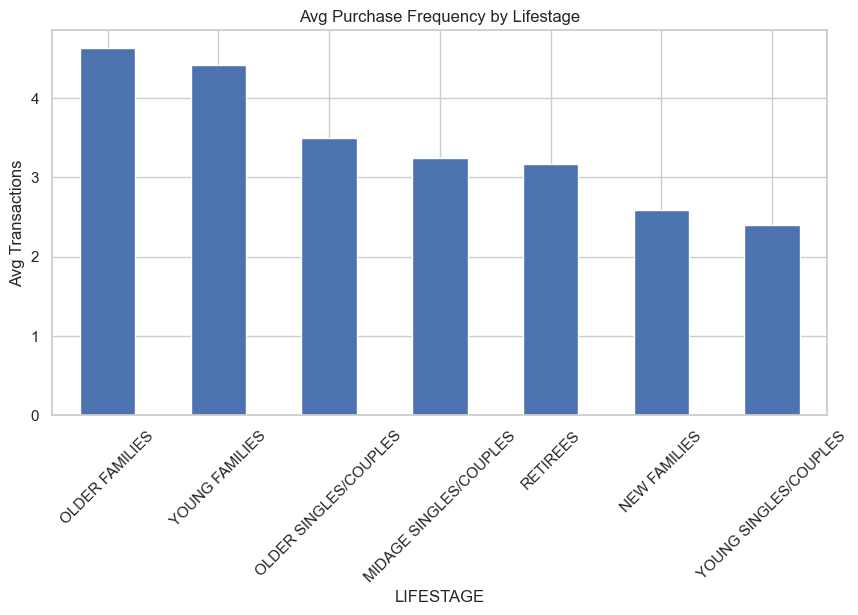


total spend per transaction: 
 LIFESTAGE
OLDER SINGLES/COUPLES     7.417791
RETIREES                  7.386466
MIDAGE SINGLES/COUPLES    7.386456
NEW FAMILIES              7.300085
YOUNG FAMILIES            7.291263
OLDER FAMILIES            7.289783
YOUNG SINGLES/COUPLES     7.189961
Name: TOT_SALES, dtype: float64



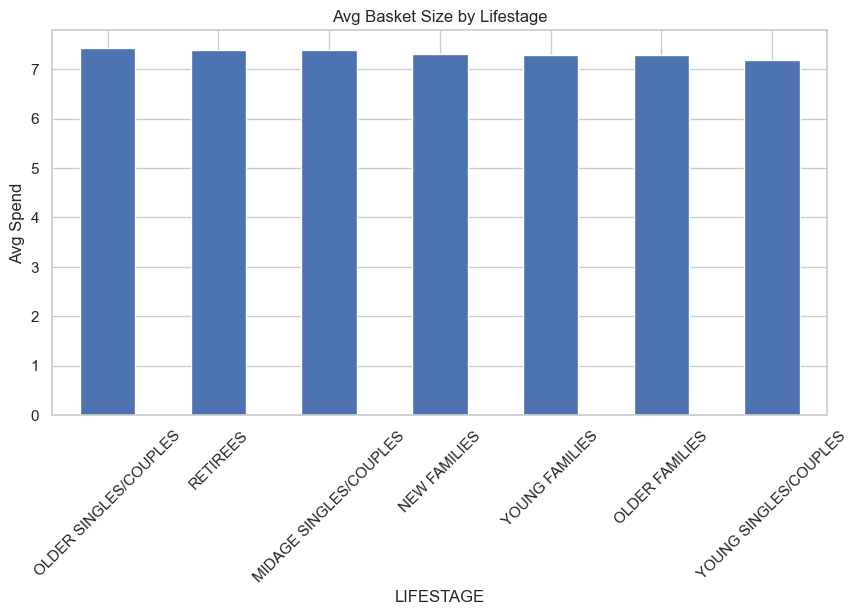


pack size preferance: 
 LIFESTAGE
YOUNG SINGLES/COUPLES     176.485068
MIDAGE SINGLES/COUPLES    176.215830
RETIREES                  176.007813
OLDER SINGLES/COUPLES     175.688130
OLDER FAMILIES            175.366901
NEW FAMILIES              175.287195
YOUNG FAMILIES            175.045526
Name: PACK_SIZE, dtype: float64



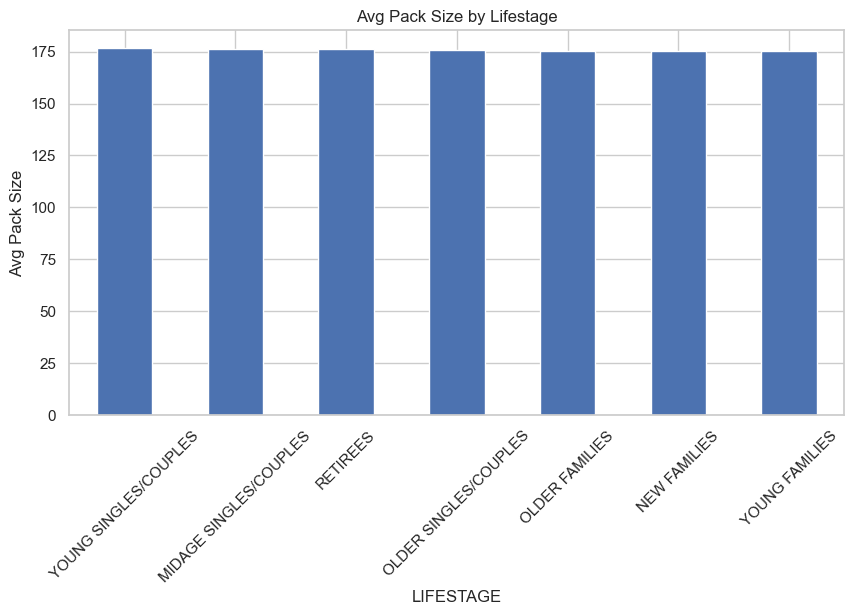

In [128]:
#purchase behaviour annalysis
#avg quantity per transaction
qty_lifestage = merged_data.groupby('LIFESTAGE')['PROD_QTY'].mean().sort_values(ascending=False)
print(f"average quantity per transaction: \n {qty_lifestage}")
print()
#visualization
qty_lifestage.plot(kind='bar', figsize=(10,5))
plt.title("Avg Quantity per Transaction by Lifestage")
plt.xticks(rotation=45)
plt.ylabel("Avg Quantity")
plt.show()

print()

#Purchase frequency
txn_per_customer = merged_data.groupby('LYLTY_CARD_NBR')['TXN_ID'].nunique()
print(f"Transaction per customer: \n {txn_per_customer.describe()}")
print()

#avg frequency by lifetstage
freq_lifestage = merged_data.groupby(['LIFESTAGE', 'LYLTY_CARD_NBR'])['TXN_ID'].nunique().groupby('LIFESTAGE').mean().sort_values(ascending=False)
print(f"average frequency by lifestage: \n {freq_lifestage}")
print()
#visualization
freq_lifestage.plot(kind='bar', figsize=(10,5))
plt.title("Avg Purchase Frequency by Lifestage")
plt.xticks(rotation=45)
plt.ylabel("Avg Transactions")
plt.show()

print()
#extracting basket size - total spend per transaction
basket_lifestage = merged_data.groupby('LIFESTAGE')['TOT_SALES'].mean().sort_values(ascending=False)
print(f"total spend per transaction: \n {basket_lifestage}")
print()
#visualization
basket_lifestage.plot(kind='bar', figsize=(10,5))
plt.title("Avg Basket Size by Lifestage")
plt.xticks(rotation=45)
plt.ylabel("Avg Spend")
plt.show()

print()

#pack size preferance
pack_lifestage = merged_data.groupby('LIFESTAGE')['PACK_SIZE'].mean().sort_values(ascending=False)
print(f"pack size preferance: \n {pack_lifestage}")
print()
#visualization
pack_lifestage.plot(kind='bar', figsize=(10,5))
plt.title("Avg Pack Size by Lifestage")
plt.xticks(rotation=45)
plt.ylabel("Avg Pack Size")
plt.show()



Customer purchase behavior indicates that families, particularly older and young families, exhibit the highest purchase frequency and slightly higher quantity per transaction, suggesting habitual and bulk buying behavior. In contrast, older singles/couples, despite lower purchase frequency, generate higher overall revenue due to consistent spending per transaction. The average basket size remains largely uniform across all segments, indicating minimal variation in per-transaction spending. Additionally, pack size preferences are nearly identical across segments, suggesting that product sizing does not significantly influence purchasing behavior. Overall, revenue differences are primarily driven by purchase frequency and segment composition rather than differences in spending per transaction or product size.

top 10 brands by revenue: 
 BRAND
Kettle           390239.8
Doritos          226329.9
Smiths           210446.0
Pringles         177655.5
Infuzions         99047.6
Thins             88852.5
Red Rock Deli     87607.5
Twisties          81522.1
Tostitos          79789.6
Cobs              70569.8
Name: TOT_SALES, dtype: float64



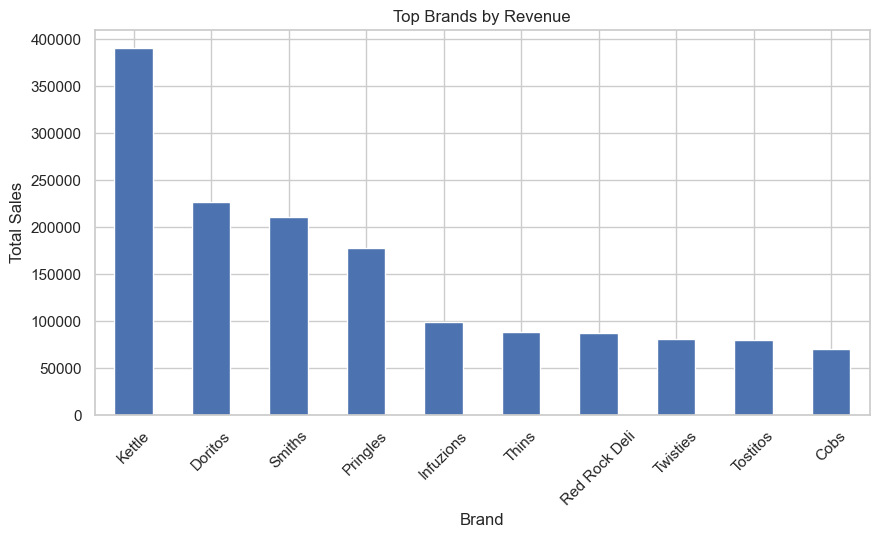


brand preferance by lifestage: 
 BRAND                   Burger Rings     CCs  Cheetos  Cheezels     Cobs  \
LIFESTAGE                                                                  
MIDAGE SINGLES/COUPLES         660.1  1717.8   1499.7    4080.6   6995.8   
NEW FAMILIES                   161.0   352.8    325.3     998.1   2059.6   
OLDER FAMILIES                1566.3  3830.4   3686.2    7002.9  12027.0   
OLDER SINGLES/COUPLES         1271.9  3385.2   3390.6    8310.0  14812.4   
RETIREES                      1131.6  2933.7   2785.5    7561.8  13687.6   
YOUNG FAMILIES                1320.2  3645.6   3261.2    6759.0  11141.6   
YOUNG SINGLES/COUPLES          719.9  2213.4   1936.0    5317.5   9845.8   

BRAND                    Doritos  French Fries  Grain Waves  Infuzions  \
LIFESTAGE                                                                
MIDAGE SINGLES/COUPLES  21568.60         654.0       4919.8     9833.4   
NEW FAMILIES             6428.35         168.0       1423.8

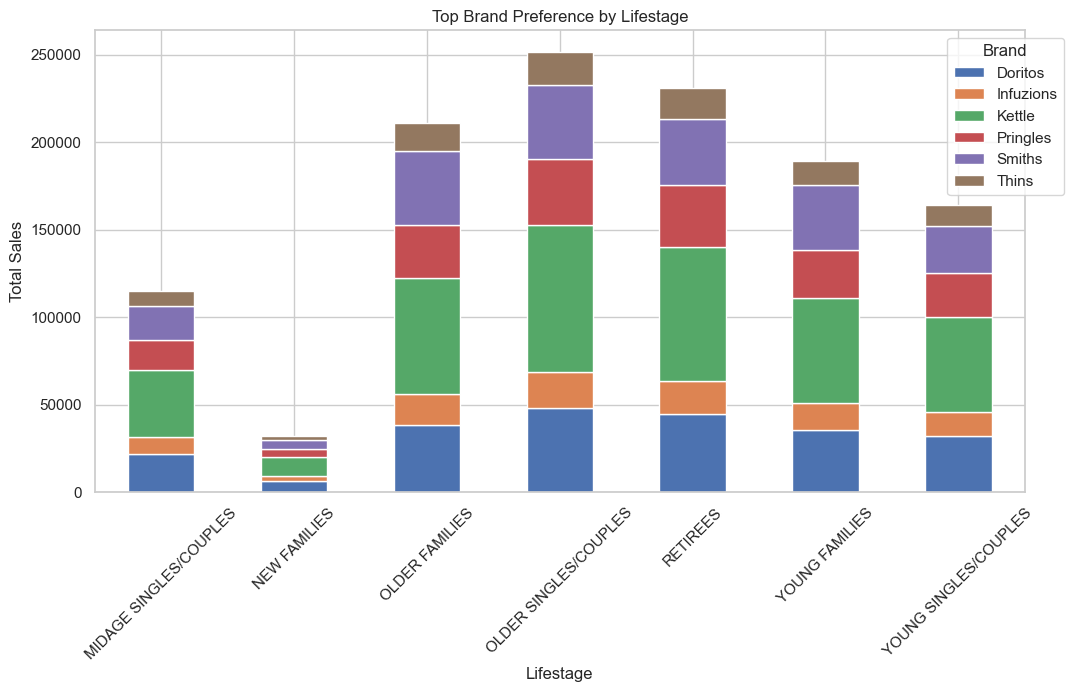


premium vs brand: 
 BRAND             Burger Rings     CCs  Cheetos  Cheezels     Cobs   Doritos  \
PREMIUM_CUSTOMER                                                               
Budget                  2527.7  6657.0   6071.6   13983.9  23780.4  78618.25   
Mainstream              2392.0  6507.9   6374.1   15303.3  28363.2  90316.70   
Premium                 1911.3  4914.0   4438.8   10742.7  18426.2  57394.95   

BRAND             French Fries  Grain Waves  Infuzions    Kettle  \
PREMIUM_CUSTOMER                                                   
Budget                  3042.0      17770.0    34272.0  134407.8   
Mainstream              2829.0      20233.6    38836.0  154477.0   
Premium                 2058.0      13613.6    25939.6  101355.0   

BRAND             Natural Chip Co  Pringles  Red Rock Deli   Smiths  Sunbites  \
PREMIUM_CUSTOMER                                                                
Budget                    15813.0   61201.7        32090.7  75315.2    3668

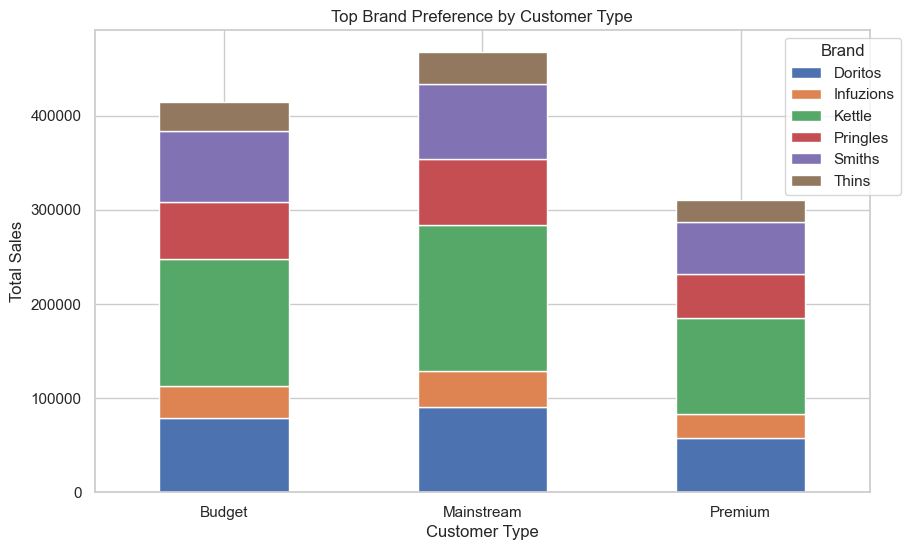

In [129]:
#top brands by revenue
brand_sales = merged_data.groupby('BRAND')['TOT_SALES'].sum().sort_values(ascending=False)
print(f"top 10 brands by revenue: \n {brand_sales.head(10)}")
print()
#visualization
brand_sales.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top Brands by Revenue")
plt.xlabel("Brand")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

print()

#brand preferance by lifestage
brand_lifestage = merged_data.groupby(['LIFESTAGE', 'BRAND'])['TOT_SALES'].sum().unstack()
print(f"brand preferance by lifestage: \n {brand_lifestage}")
print()
#visual
#filtering top brands as stacked charts will be messy with 21 brands
top_brands = brand_sales.head(6).index
brand_lifestage_filtered = merged_data[
    merged_data['BRAND'].isin(top_brands)
]
brand_lifestage_clean = brand_lifestage_filtered.groupby(
    ['LIFESTAGE', 'BRAND']
)['TOT_SALES'].sum().unstack()
brand_lifestage_clean.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Top Brand Preference by Lifestage")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1))
plt.show()

print()

#premium vs brand
brand_premium = merged_data.groupby(['PREMIUM_CUSTOMER', 'BRAND'])['TOT_SALES'].sum().unstack()
print(f"premium vs brand: \n {brand_premium}")
print()
#visual
brand_premium_filtered = merged_data[
    merged_data['BRAND'].isin(top_brands)
]

brand_premium_clean = brand_premium_filtered.groupby(
    ['PREMIUM_CUSTOMER', 'BRAND']
)['TOT_SALES'].sum().unstack()

brand_premium_clean.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Top Brand Preference by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1))
plt.show()

print()



Brand analysis reveals that Kettle is the clear market leader, significantly outperforming all other brands in total revenue, followed by Doritos and Smiths as strong mass-market competitors. Brand preference is largely consistent across all customer segments, indicating that no single segment shows exclusive loyalty to a specific brand. Mainstream customers contribute the highest sales across most brands, reinforcing their importance as the core revenue-driving segment. Premium customers do not display significantly different brand preferences, suggesting that purchasing behavior is more volume-driven rather than brand differentiation-driven. Overall, top-performing brands dominate uniformly across segments, highlighting limited brand segmentation but strong category leaders.

In [130]:
#figuring out the real drivers of revenue
segment_sales = merged_data.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
)['TOT_SALES'].sum().sort_values(ascending=False)

print(f"Which segments truly drive revenue? \nBelow are the top 10 major revenue drivers: \n {segment_sales.head(10)}")
print()
#purchase style analysis
deep_dive = merged_data.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
).agg({
    'TOT_SALES': 'mean',
    'PROD_QTY': 'mean',
    'TXN_ID': 'nunique'
})

print(f"Do premium customers behave differently? \nBelow is the purchase style of customers: \n {deep_dive.sort_values(by='TOT_SALES', ascending=False).head(10)}")
print()

#pack size impact
pack_impact = merged_data.groupby('PACK_SIZE')['TOT_SALES'].sum().sort_values(ascending=False)

print(f" Does pack size influence purchases? \nBelow is the pack size impact on customers: \n {pack_impact.head(10)}")
print()


Which segments truly drive revenue? 
Below are the top 10 major revenue drivers: 
 LIFESTAGE              PREMIUM_CUSTOMER
OLDER FAMILIES         Budget              156096.75
YOUNG SINGLES/COUPLES  Mainstream          147244.20
RETIREES               Mainstream          144677.55
YOUNG FAMILIES         Budget              129151.15
OLDER SINGLES/COUPLES  Budget              127279.80
                       Mainstream          124089.50
                       Premium             123147.55
RETIREES               Budget              105586.10
OLDER FAMILIES         Mainstream           96059.95
RETIREES               Premium              91013.25
Name: TOT_SALES, dtype: float64

Do premium customers behave differently? 
Below is the purchase style of customers: 
                                          TOT_SALES  PROD_QTY  TXN_ID
LIFESTAGE              PREMIUM_CUSTOMER                             
MIDAGE SINGLES/COUPLES Mainstream         7.648466  1.911930   10988
YOUNG SINGLES/COUPLES

“Revenue is primarily driven by high-frequency, mass-market segments rather than premium customers. Older families (Budget) and young singles/couples (Mainstream) emerge as the strongest contributors, indicating that both family-oriented bulk buyers and frequent individual consumers play key roles in revenue generation. Premium customers do not exhibit significantly different purchasing behavior, as average spend per transaction and quantity remain consistent across all segments, suggesting that higher pricing tiers do not translate into higher per-transaction value. Instead, revenue differences are driven mainly by purchase frequency. Additionally, pack size analysis reveals that the 175g pack dominates sales by a large margin, followed by mid-sized packs (150g, 134g), indicating a strong consumer preference for standard-sized products. Overall, customer behavior is volume-driven rather than price- or brand-driven, with frequency and segment size being the primary revenue drivers.

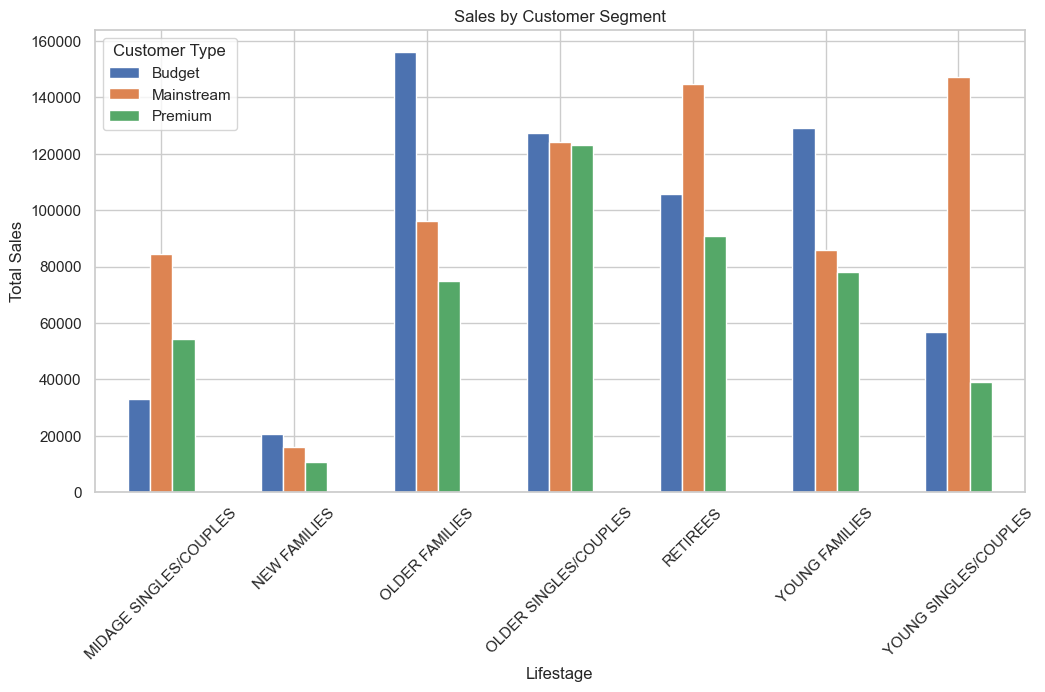

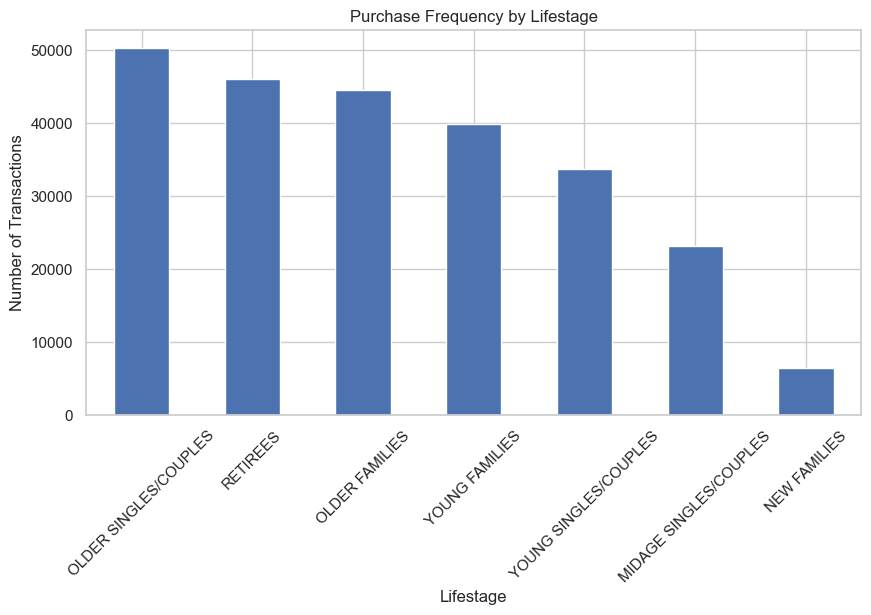

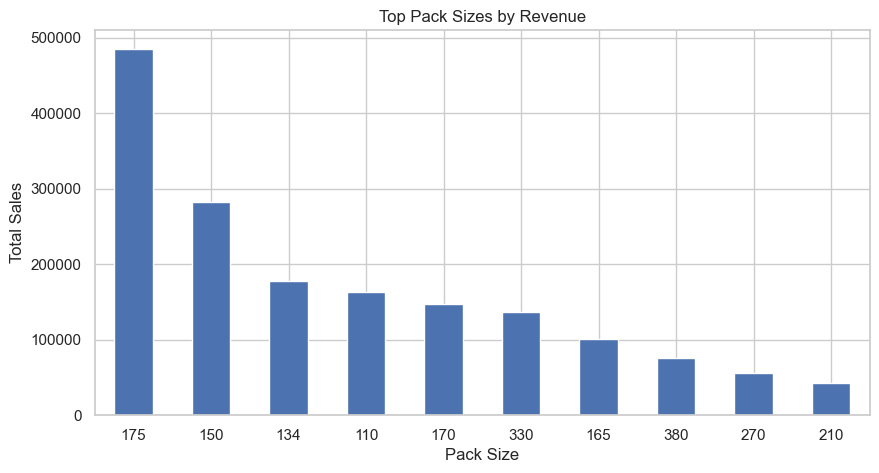

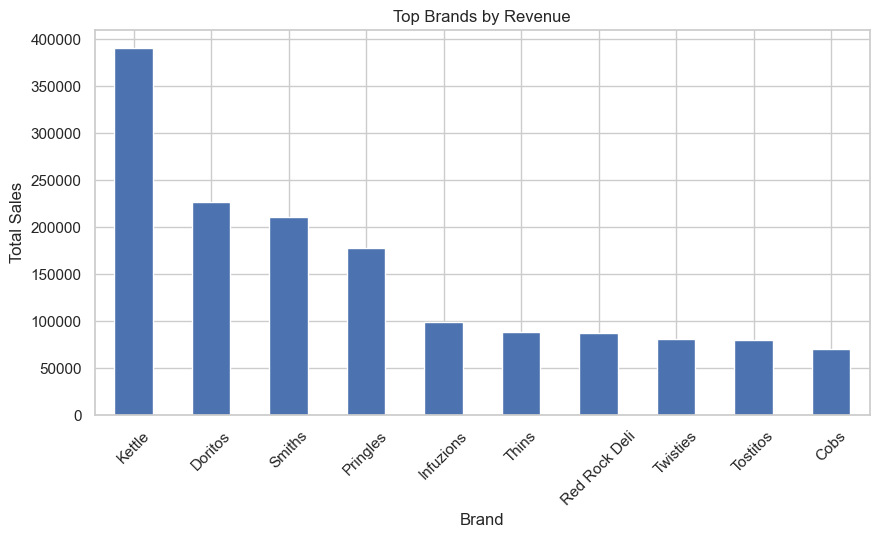

In [131]:
# visulaizations:
# sales by segment
segment_sales = merged_data.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
)['TOT_SALES'].sum().unstack()

segment_sales.plot(kind='bar', figsize=(12,6))

plt.title("Sales by Customer Segment")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.legend(title="Customer Type")
plt.show()

print()

#purchase frequency key driver
freq = merged_data.groupby('LIFESTAGE')['TXN_ID'].nunique().sort_values(ascending=False)

freq.plot(kind='bar', figsize=(10,5))

plt.title("Purchase Frequency by Lifestage")
plt.xlabel("Lifestage")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.show()
print()

#pack size impact
pack_impact.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top Pack Sizes by Revenue")
plt.xlabel("Pack Size")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.show()
print()

#top brands
brand_sales.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top Brands by Revenue")
plt.xlabel("Brand")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

Visual analysis reinforces that revenue is driven by a combination of high-frequency segments and dominant product preferences. Older singles/couples and retirees exhibit the highest transaction volumes, confirming that frequent purchasing behavior is a key driver of sales. Segment-wise sales distribution shows that both budget and mainstream customers contribute significantly across all lifestages, with no heavy reliance on premium customers. Pack size analysis highlights a strong and consistent preference for the 175g pack, followed by mid-sized options such as 150g and 134g, indicating standardized consumption patterns across the customer base. Brand-wise, Kettle clearly dominates the market, with Doritos and Smiths acting as strong secondary players. Overall, the visuals confirm that sales performance is driven more by frequency and widely accepted product formats rather than niche preferences or premium segmentation.

<center> FINAL INSIGHTS </center>

1. Revenue is primarily driven by Older Families, Older Singles/Couples, and Retirees.
2. Mainstream and Budget customers contribute the majority of total sales.
3. Purchase frequency is the key driver of revenue, not higher spending per transaction.
4. Average transaction value remains consistent across all customer segments.
5. The 175g pack size dominates sales, indicating strong preference for standard-sized products.
6. Kettle, Doritos, and Smiths are the leading brands with consistent performance across segments.
7. There is minimal differentiation in behavior between Premium and non-premium customers.

STRATEGIC BUSINESS RECCOMONDATIONS

1️ Target Customer Segments

Focus on Older Families, Older Singles/Couples, and Retirees, as they are the most consistent and high-frequency revenue drivers.
Older Families → high volume + high frequency (bulk buyers)
Older Singles/Couples → highest transaction frequency
Retirees → stable and repeat purchases

Action:

Prioritize these segments in store placement, promotions, and loyalty programs

2️ Product Strategy

Double down on high-performing pack sizes and dominant brands
175g pack → clear winner (core product)
150g & 134g → secondary strong performers
Kettle, Doritos, Smiths → must-stock, high-visibility brands

Action:

Ensure maximum shelf visibility for 175g packs
Bundle mid-size packs (150g/134g) for upselling
Expand SKUs for top brands instead of low-performing ones

3️ Pricing Strategy

Avoid over-emphasis on premium pricing — behavior is not price-sensitive
Premium customers do NOT spend significantly more per transaction
Revenue is driven by frequency, not margin per purchase

Action:

Focus on value-based pricing
Introduce multi-buy offers (e.g., 2 for X pricing)
Use discounts to increase frequency, not just margins

4️ Marketing Strategy

Target habit-driven consumption, not luxury positioning
Customers behave similarly across segments
No strong premium-brand loyalty observed

Action that should be taken:

1 Promote “Everyday snack” positioning, Family sharing packs
2 Run campaigns like - “Stock up & save”, “Weekly snack essentials”
3 Use in-store promotions & visibility over brand storytelling


SUMMARY -

The chips category is driven by high-frequency, mainstream consumption rather than premium differentiation. Core segments such as older families and older singles/couples generate the most revenue due to repeat purchases, while product success is concentrated around standard pack sizes, particularly 175g. Leading brands like Kettle, Doritos, and Smiths dominate uniformly across all segments, indicating low brand segmentation. Strategic focus should therefore be on maximizing availability, promoting high-frequency purchases through value-based pricing, and targeting core consumer groups with practical, habit-driven marketing.

<h1><center> Task 2 </h1>
Phase 1: Data Preparation </h1>

In [132]:
# Ensure DATE is datetime (already done, but safe check)
merged_data['DATE'] = pd.to_datetime(merged_data['DATE'])

# Create MONTH_ID (YYYY-MM format)
merged_data['MONTH_ID'] = merged_data['DATE'].dt.to_period('M')

print(merged_data.head())
print()
# Check number of months per store
store_months = merged_data.groupby('STORE_NBR')['MONTH_ID'].nunique()

print(f"store months per store:\n{store_months}")
print()
# Keep only stores with full 12 months data
valid_stores = store_months[store_months == 12].index

data = merged_data[merged_data['STORE_NBR'].isin(valid_stores)].copy()
print(data.head())

        DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0 2018-10-17          1            1000       1         5   
1 2019-05-14          1            1307     348        66   
2 2019-05-20          1            1343     383        61   
3 2018-08-17          2            2373     974        69   
4 2018-08-18          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  PACK_SIZE  \
0    Natural Chip        Compny SeaSalt175g         2        6.0        175   
1                  CCs Nacho Cheese    175g         3        6.3        175   
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9        170   
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0        175   
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8        150   

             BRAND               LIFESTAGE PREMIUM_CUSTOMER MONTH_ID  
0  Natural Chip Co   YOUNG SINGLES/COUPLES          Premium  2018-10  
1              C

phase 2: metric creation

In [133]:
# Aggregate to store-month level
store_monthly = data.groupby(['STORE_NBR', 'MONTH_ID']).agg(
    TOT_SALES=('TOT_SALES', 'sum'),
    N_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
    N_TXN=('TXN_ID', 'nunique')
).reset_index()

# Transactions per customer
store_monthly['TXN_PER_CUSTOMER'] = store_monthly['N_TXN'] / store_monthly['N_CUSTOMERS']

print(f"details of store per month: \n{store_monthly.head(12)}")


details of store per month: 
    STORE_NBR MONTH_ID  TOT_SALES  N_CUSTOMERS  N_TXN  TXN_PER_CUSTOMER
0           1  2018-07      188.9           47     49          1.042553
1           1  2018-08      168.4           41     41          1.000000
2           1  2018-09      268.1           57     59          1.035088
3           1  2018-10      175.4           39     40          1.025641
4           1  2018-11      184.8           44     45          1.022727
5           1  2018-12      160.6           37     40          1.081081
6           1  2019-01      144.5           33     33          1.000000
7           1  2019-02      192.1           48     50          1.041667
8           1  2019-03      185.2           43     47          1.093023
9           1  2019-04      177.4           39     40          1.025641
10          1  2019-05      201.9           41     46          1.121951
11          1  2019-06      161.0           38     38          1.000000


Average transactions per customer ≈ 1.0–1.1
Customers typically buy once per visit
Growth must come from:
More customers (footfall), not frequency

phase 3 : control store selection

In [134]:
# Define periods
pre_trial = store_monthly[
    (store_monthly['MONTH_ID'] >= '2018-07') &
    (store_monthly['MONTH_ID'] <= '2019-01')
]

trial_stores = [77, 86, 88]


def get_control_store(trial_store):
    trial_data = pre_trial[pre_trial['STORE_NBR'] == trial_store]

    correlations = []

    for store in pre_trial['STORE_NBR'].unique():
        if store == trial_store:
            continue
        
        control_data = pre_trial[pre_trial['STORE_NBR'] == store]
        
        # Merge on month
        merged = pd.merge(
            trial_data,
            control_data,
            on='MONTH_ID',
            suffixes=('_trial', '_control')
        )
        
        if len(merged) < 2:
            continue
        
        corr, _ = pearsonr(
            merged['TOT_SALES_trial'],
            merged['TOT_SALES_control']
        )
        
        correlations.append((store, corr))
    
    # Sort by highest correlation
    correlations = sorted(correlations, key=lambda x: x[1], reverse=True)
    
    return correlations[0], correlations[:5]

# Get control stores
control_mapping = {}

for store in trial_stores:
    best, top5 = get_control_store(store)
    control_mapping[store] = best[0]
    
    print(f"Trial Store {store} → Control Store {best[0]} (corr={best[1]:.2f})")

Trial Store 77 → Control Store 233 (corr=0.95)
Trial Store 86 → Control Store 155 (corr=0.84)
Trial Store 88 → Control Store 91 (corr=0.91)


Store 77 & 88 comparisons are highly reliable
Store 86 is slightly weaker → results less confident

phase 4 validation

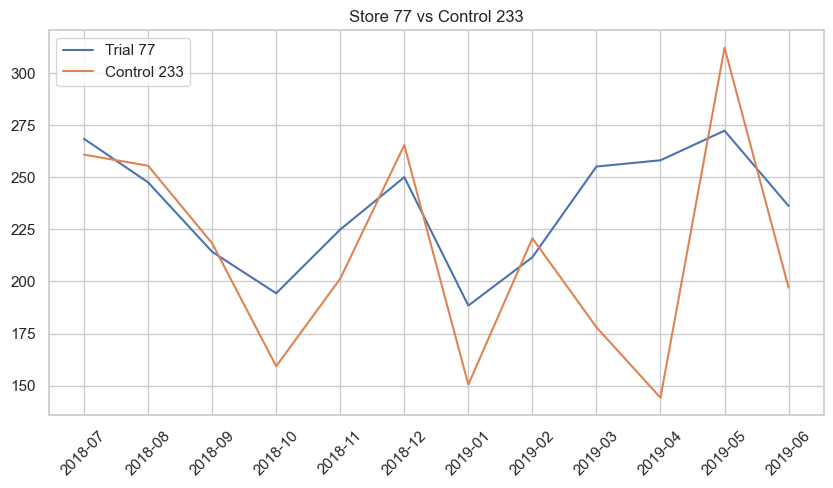

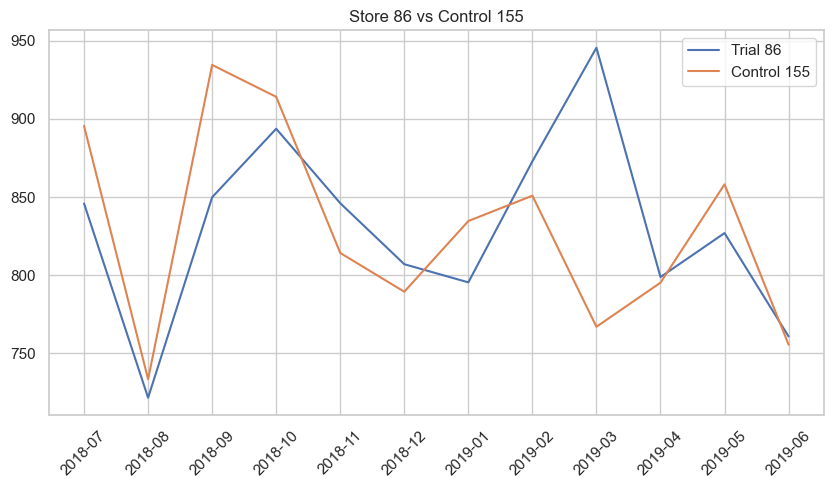

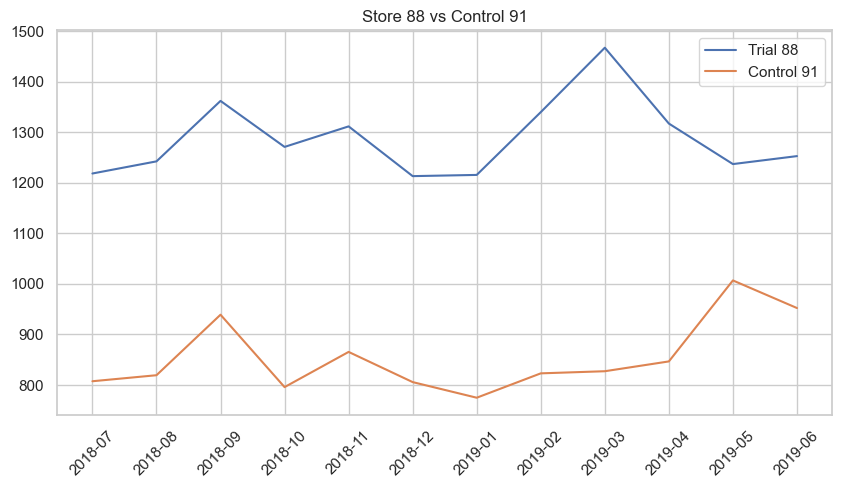

In [135]:

def plot_trial_vs_control(trial, control):
    trial_data = store_monthly[store_monthly['STORE_NBR'] == trial]
    control_data = store_monthly[store_monthly['STORE_NBR'] == control]

    merged = pd.merge(trial_data, control_data, on='MONTH_ID', suffixes=('_trial', '_control'))

    plt.figure(figsize=(10,5))
    plt.plot(merged['MONTH_ID'].astype(str), merged['TOT_SALES_trial'], label=f'Trial {trial}')
    plt.plot(merged['MONTH_ID'].astype(str), merged['TOT_SALES_control'], label=f'Control {control}')
    
    plt.title(f"Store {trial} vs Control {control}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

# Validate all
for trial, control in control_mapping.items():
    plot_trial_vs_control(trial, control)

Store 88 control is trend-similar but NOT magnitude-similar
→ This inflates uplift artificially

phase 5 trial impact analysis

In [136]:
trial_period = store_monthly[
    (store_monthly['MONTH_ID'] >= '2019-02') &
    (store_monthly['MONTH_ID'] <= '2019-04')
]

results = []

for trial, control in control_mapping.items():
    trial_sales = trial_period[trial_period['STORE_NBR'] == trial]['TOT_SALES'].sum()
    control_sales = trial_period[trial_period['STORE_NBR'] == control]['TOT_SALES'].sum()
    
    uplift = (trial_sales - control_sales) / control_sales * 100
    
    results.append({
        'Trial Store': trial,
        'Control Store': control,
        'Trial Sales': trial_sales,
        'Control Sales': control_sales,
        '% Uplift': uplift
    })

results_df = pd.DataFrame(results)
results_df

,Trial Store,Control Store,Trial Sales,Control Sales,% Uplift
0,77,233,724.8,542.9,33.505250
1,86,155,2617.0,2413.0,8.454206
2,88,91,4123.6,2496.5,65.175245


Store 88 looks too good → needs validation (Phase 6)

phase 6 statisitcal testing

In [137]:
from scipy.stats import ttest_ind

stat_results = []

for trial, control in control_mapping.items():
    trial_data = trial_period[trial_period['STORE_NBR'] == trial]['TOT_SALES']
    control_data = trial_period[trial_period['STORE_NBR'] == control]['TOT_SALES']
    
    t_stat, p_value = ttest_ind(trial_data, control_data)
    
    stat_results.append({
        'Trial Store': trial,
        'p-value': p_value,
        'Significant': p_value < 0.05
    })

pd.DataFrame(stat_results)

,Trial Store,p-value,Significant
0,77,0.086055,False
1,86,0.237195,False
2,88,0.000329,True


Store 88 → Statistically significant growth
hence a Real impact

Store 77 → borderline (close to 0.05) - Likely real but not strongly proven

Store 86 → clearly NOT significant -  No real impact

phase 7 driver analysis

In [138]:
drivers = []

for trial, control in control_mapping.items():
    trial_data = trial_period[trial_period['STORE_NBR'] == trial]
    control_data = trial_period[trial_period['STORE_NBR'] == control]
    
    # Aggregate
    trial_metrics = trial_data[['N_CUSTOMERS', 'TXN_PER_CUSTOMER', 'TOT_SALES']].mean()
    control_metrics = control_data[['N_CUSTOMERS', 'TXN_PER_CUSTOMER','TOT_SALES']].mean()
    
    drivers.append({
        'Store': trial,
        'Customer Change': trial_metrics['N_CUSTOMERS'] - control_metrics['N_CUSTOMERS'],
        'Txn per Customer Change': trial_metrics['TXN_PER_CUSTOMER'] - control_metrics['TXN_PER_CUSTOMER'],
        'Avg Spend Change': trial_metrics['TOT_SALES'] - control_metrics['TOT_SALES']
    })

pd.DataFrame(drivers)

,Store,Customer Change,Txn per Customer Change,Avg Spend Change
0,77,10.000000,0.006146,60.633333
1,86,11.666667,-0.022243,68.000000
2,88,41.666667,0.089889,542.366667


Layout attracted more people
But did not change buying behavior

phase 8 visualization

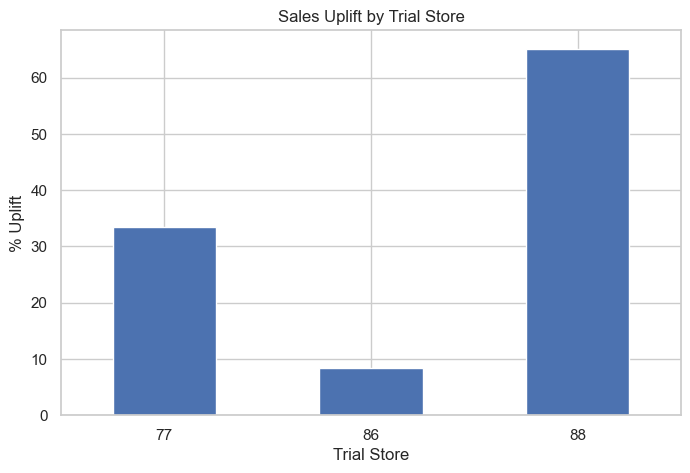

In [139]:
# Uplift bar chart
results_df.set_index('Trial Store')['% Uplift'].plot(kind='bar', figsize=(8,5))
plt.title("Sales Uplift by Trial Store")
plt.ylabel("% Uplift")
plt.xticks(rotation=0)
plt.show()

Visuals strongly support numerical findings, especially:

Store 88 spike
Store 77 steady growth
Store 86 weak impact

<h2><center>Final insights and Summary with Business recommandations

The trial store analysis indicates that the impact of the new layout was not uniform across all locations. Among the three trial stores, Store 88 demonstrated a strong and statistically significant improvement in sales performance during the trial period, while Store 77 showed a moderate uplift that was not statistically significant. Store 86 exhibited only marginal improvement, with no statistical evidence to support a meaningful impact.

A deeper examination of performance drivers reveals that the primary contributor to sales uplift was an increase in the number of customers visiting the stores. Across all trial locations, there was minimal change in transactions per customer, indicating that purchasing behavior remained largely unchanged. This suggests that the trial layout was effective in attracting more customers into the store but did not significantly influence how much customers purchased once inside.

It is also important to note that the reliability of results varies across stores due to differences in control store comparability. While Stores 77 and 88 had strong pre-trial alignment with their respective control stores, Store 86 showed weaker alignment, reducing confidence in its results. Additionally, although Store 88 demonstrated significant uplift, the difference in scale between the trial and control store suggests that part of the observed effect may be amplified due to structural differences.

Overall, the trial layout appears to be effective in improving store performance, but its success is dependent on store-specific factors such as baseline performance, customer mix, and store characteristics.


<center><h3> Business Recommendations</h3></center>


Based on the analysis, a full-scale rollout of the trial layout across all stores is not recommended. Instead, a targeted implementation strategy should be adopted.

The trial should be extended to stores that share similar characteristics with Store 88 and, to a lesser extent, Store 77, where positive performance impact was observed. These stores are more likely to benefit from layout changes that enhance visibility and attract customer traffic.

For stores similar to Store 86, further investigation is required before implementing any changes. The lack of measurable impact suggests that layout alone may not be sufficient to drive performance improvements in these locations.

Given that the primary driver of uplift was increased customer count rather than changes in purchasing behavior, future strategies should focus on enhancing customer acquisition. This can be achieved through improved store layout design, better product placement, and increased in-store visibility.

At the same time, there is a clear opportunity to improve basket size and customer spend per visit. Complementary initiatives such as product bundling, promotional offers, and cross-selling strategies should be introduced alongside layout changes to maximize revenue per customer.

Finally, it is recommended to conduct additional trials across a broader set of stores with improved control matching techniques. This will help validate the scalability of the results and ensure that future decisions are based on robust and generalizable evidence.